## 4. TensorFlow der multivariaten linearen Regression auf California Housing


In [1]:
from sklearn.datasets import fetch_california_housing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

print("TensorFlow-Version:", tf.__version__)

2026-03-27 12:40:24.686848: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow-Version: 2.14.0


In [2]:
# Datensatz laden
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

print("Feature-Matrix:", X.shape)
print("Zielvariable:", y.shape)
display(X.head())
display(y.head())

Feature-Matrix: (20640, 8)
Zielvariable: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [4]:
# Train-Test- Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (16512, 8) (16512,)
Test : (4128, 8) (4128,)


### 4.1 Daten vorbereiten

In [5]:
# Features standardisieren
scaler_tf = StandardScaler()
X_train_tf = scaler_tf.fit_transform(X_train)
X_test_tf = scaler_tf.transform(X_test)

# Zielvariable als NumPy-Array
y_train_tf = np.array(y_train)
y_test_tf = np.array(y_test)

print("X_train_tf:", X_train_tf.shape)
print("X_test_tf :", X_test_tf.shape)

X_train_tf: (16512, 8)
X_test_tf : (4128, 8)


### 4.2 Modell definieren

In [13]:
tf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_tf.shape[1],)),
    tf.keras.layers.Dense(1)
])

tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

tf_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 9         
                                                                 
Total params: 9 (36.00 Byte)
Trainable params: 9 (36.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### 4.3 Training

In [7]:
history = tf_model.fit(
    X_train_tf,
    y_train_tf,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
413/413 [==============================] - 1s 842us/step - loss: 5.9786 - mae: 1.9488 - val_loss: 4.7310 - val_mae: 1.7495
Epoch 2/100
413/413 [==============================] - 0s 653us/step - loss: 3.6217 - mae: 1.5276 - val_loss: 2.8877 - val_mae: 1.3637
Epoch 3/100
413/413 [==============================] - 0s 655us/step - loss: 2.2446 - mae: 1.1863 - val_loss: 1.8169 - val_mae: 1.0461
Epoch 4/100
413/413 [==============================] - 0s 652us/step - loss: 1.4410 - mae: 0.9078 - val_loss: 1.1990 - val_mae: 0.7954
Epoch 5/100
413/413 [==============================] - 0s 652us/step - loss: 0.9815 - mae: 0.7080 - val_loss: 0.8576 - val_mae: 0.6362
Epoch 6/100
413/413 [==============================] - 0s 662us/step - loss: 0.7316 - mae: 0.5911 - val_loss: 0.6814 - val_mae: 0.5583
Epoch 7/100
413/413 [==============================] - 0s 651us/step - loss: 0.6072 - mae: 0.5389 - val_loss: 0.6002 - val_mae: 0.5331
Epoch 8/100
413/413 [==============================] - 

### 4.4 Auswertung

In [9]:
y_pred_tf = tf_model.predict(X_test_tf).flatten()

mse_tf = mean_squared_error(y_test_tf, y_pred_tf)
rmse_tf = np.sqrt(mse_tf)
mae_tf = mean_absolute_error(y_test_tf, y_pred_tf)
r2_tf = r2_score(y_test_tf, y_pred_tf)

print("TensorFlow-Ergebnisse:")
print("MSE :", mse_tf)
print("RMSE:", rmse_tf)
print("MAE :", mae_tf)
print("R²  :", r2_tf)

129/129 [==============================] - 0s 436us/step
TensorFlow-Ergebnisse:
MSE : 0.559418675360234
RMSE: 0.7479429626383512
MAE : 0.5335751316605428
R²  : 0.573096121402342


In [11]:
weights_tf, bias_tf = tf_model.layers[0].get_weights()

coef_table_tf = pd.DataFrame({
    "Feature": X.columns,
    "Koeffizient (TensorFlow)": weights_tf.flatten()
}).sort_values("Koeffizient (TensorFlow)", key=np.abs, ascending=False)

print("Bias / Intercept:", bias_tf[0])
coef_table_tf

Bias / Intercept: 2.0714


,Feature,Koeffizient (TensorFlow)
6,Latitude,-0.905316
7,Longitude,-0.871697
0,MedInc,0.865305
3,AveBedrms,0.358556
2,AveRooms,-0.310565
1,HouseAge,0.123491
5,AveOccup,-0.036730
4,Population,-0.010297


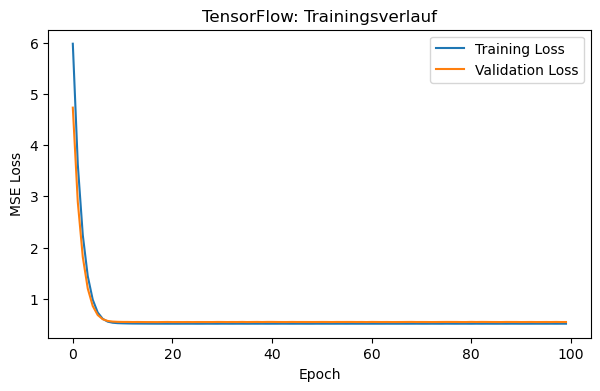

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("TensorFlow: Trainingsverlauf")
plt.legend()
plt.show()